In [3]:
using CairoMakie, LaTeXStrings, JLD2
include("Utils.jl")
include("FigureStyles.jl")
using .Utils
using .FigureStyles

## Compare Novikov's theorem and time-domain integration

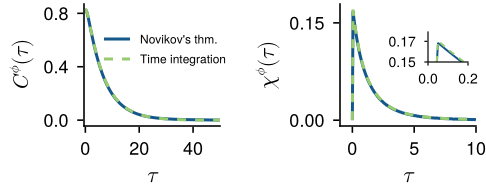

CairoMakie.Screen{IMAGE}


In [4]:
# Run CompareStationaryDMFTAlgo.jl
data = load("results/DMFTChaosAlgoComp.jld2")
Cϕ = data["Cϕ"]
χϕ = data["χϕ"]
CϕFN = data["CϕFN"]
χϕFN = data["χϕFN"]
model = data["model_data"]
dt = model.dt
times = 0:dt:(length(Cϕ)-1)*dt;
set_theme!(SingleColumnTheme)
f22 = Figure(size=(3.375*72, 1.3*72), figure_padding=(5,5,2,2))
dmft_colors = cgrad(:navia, 10, categorical=true)
colors = dmft_colors[[3, 8]]
linewidth = 1.5
ax1 = Axis(f22[1, 1], xlabel=L"\tau", ylabel=L"C^{\phi}(\tau)", limits=(-0.5, 50.0, nothing, nothing), 
yticks=[0.0,0.4,0.8], xticksize=3)
ax2 = Axis(f22[1, 2], xlabel=L"\tau", ylabel=L"\chi^{\phi}(\tau)", yticks=[0.0,0.15],
 limits=(-1.0, 10.0, nothing, nothing))
lines!(ax1, times, CϕFN; linewidth=linewidth, color=colors[1], label="Novikov's thm.")
lines!(ax1, times, Cϕ; linestyle=:dash, linewidth=linewidth, color=colors[2], label="Time integration")
lines!(ax2, times, χϕFN; linewidth=linewidth, color=colors[1])
lines!(ax2, times, χϕ; linestyle=:dash, linewidth=linewidth, color=colors[2])
ax2_inset = Axis(f22[1, 2],
    width=Relative(0.3), height=Relative(0.25),
    halign=0.92, valign=0.7, xticks=[0,0.2], yticks=[0.15, 0.17],
    limits=(0, 0.2, 0.15, nothing), xticksize=1.5, yticksize=1.5, xticklabelsize=7, 
    yticklabelsize=7, xtickwidth=0.6, ytickwidth=0.6, spinewidth=0.6)
lines!(ax2_inset, times, χϕFN; linewidth=1.0, color=colors[1])
lines!(ax2_inset, times, χϕ; linestyle=:dash, linewidth=1.0, color=colors[2])
axislegend(ax1, position=(0.1, 0.9), patchsize=(13, 2), labelsize=6)
filename = "NovikovVSTimeInteg_g$(replace(string(model.g), "."=>"p"))" *
           "taurec$(replace(string(model.τ[2]), "."=>"p"))" *"dt$(replace(string(model.dt), "."=>"p")).pdf"
# save("images/"*filename, f22, pt_per_unit=1)
display(f22)

## Investigate fluctuations of the eigenspectrum and non-unimodal distribution of $\langle x (t)\rangle$ for isolated $\tau^{\mathrm{con}}$

In [3]:
# Run ConDivOutlier.jl
data = load("results/ConDivOutlier.jld2")

Dict{String, Any} with 9 entries:
  "largest_real_parts_con" => [2.9004 2.9962 2.98014 3.36776; 3.00197 3.0477 3.…
  "scan_seed"              => 12345
  "n_samples"              => 200
  "τ_div_vec"              => [0.0, 0.1, 0.2, 0.3]
  "N_vec"                  => [1000, 2000, 4000]
  "τ_con_vec"              => [0.0, 0.1, 0.2, 0.3]
  "g_eff"                  => 3.0
  "largest_real_parts_div" => [3.00331 3.32579 3.11332 3.08749; 2.9962 3.12093 …
  "J0"                     => 0.0

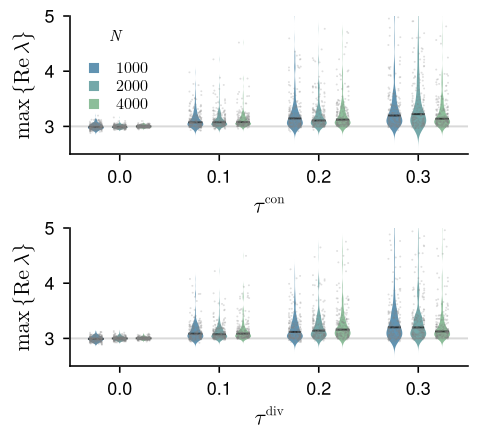

CairoMakie.Screen{IMAGE}


In [ ]:
set_theme!(SingleColumnTheme)

N_vec = data["N_vec"]
τ_con_vec = data["τ_con_vec"]
τ_div_vec = data["τ_div_vec"]
largest_real_parts_con = data["largest_real_parts_con"]
largest_real_parts_div = data["largest_real_parts_div"]

foutlier = Figure(size=(3.375*72, 3.0*72), figure_padding=(6, 9, 2, 8))
colors = cgrad(:navia, 12, categorical=true)[[4, 6, 8]]
offsets = range(-0.24, 0.24; length=length(N_vec))
violin_width = 0.20

function plot_outlier_violins!(ax, largest_real_parts, τ_vec)
    for (iτ, _) in enumerate(τ_vec)
        for (iN, _) in enumerate(N_vec)
            samples = vec(largest_real_parts[iN, iτ, :])
            x = fill(iτ + offsets[iN], length(samples))
            violin!(ax, x, samples; width=violin_width, color=(colors[iN], 0.7), show_median=true,
            medianlinewidth=1.0, mediancolor=(0.1,0.1,0.1,0.8))
            jitter = 0.06 .* sin.(2.399963 .* eachindex(samples))
            scatter!(ax, x .+ jitter, samples; markersize=1.4, color=(:gray, 0.25))
        end
    end
    ax.xticks = (1:length(τ_vec), string.(τ_vec))
    xlims!(ax, 0.5, length(τ_vec) + 0.5)
end

ax_con = Axis(foutlier[1, 1], xlabel=L"\tau^{\mathrm{con}}", ylabel=L"\max\,\{\mathrm{Re}\,\lambda\}",
    yticks=[3.0, 4.0, 5.0])
ax_div = Axis(foutlier[2, 1], xlabel=L"\tau^{\mathrm{div}}", ylabel=L"\max\,\{\mathrm{Re}\,\lambda\}",
    yticks=[3.0, 4.0, 5.0])

plot_outlier_violins!(ax_con, largest_real_parts_con, τ_con_vec)
plot_outlier_violins!(ax_div, largest_real_parts_div, τ_div_vec)
linkyaxes!(ax_con, ax_div)
ylims!(ax_con, 2.5, 5.0)
hlines!(ax_con, 3.0; color=:gray, alpha=0.3, linestyle=:solid, linewidth=1.0)
hlines!(ax_div, 3.0; color=:gray, alpha=0.3, linestyle=:solid, linewidth=1.0)

legend_labels = [L"%$(N)" for N in N_vec]
legend_elements = [
    MarkerElement(marker=:rect, color=(colors[i], 0.7), markersize=8)
    for i in eachindex(N_vec)
]
Legend(foutlier[1, 1], legend_elements, legend_labels, L"N";
    tellwidth=false,
    tellheight=false,
    halign=:left,
    valign=:top,
    titlesize=8,
    patchsize=(12, 8),
    rowgap=1,
)
rowgap!(foutlier.layout, 6)
# save("images/ConDivOutlier.pdf", foutlier, pt_per_unit=1)
display(foutlier)

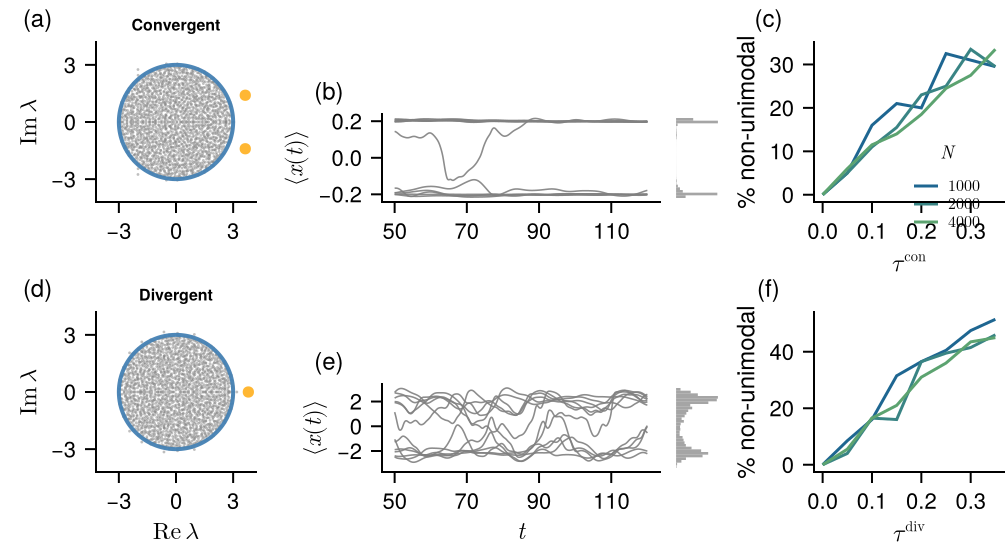

CairoMakie.Screen{IMAGE}


In [16]:
# Run DipTest.jl
data = load("results/DipTest.jld2")
set_theme!(DoubleColumnTheme)

N_vec = data["N_vec"]
τ_con_vec = data["τ_con_vec"]
τ_div_vec = data["τ_div_vec"]
non_unimodal_fraction_con = data["non_unimodal_fraction_con"]
non_unimodal_fraction_div = data["non_unimodal_fraction_div"]
example_con = data["example_con"]
example_div = data["example_div"]
g_eff = data["g_eff"]
example_times = data["example_times"]

fdip = Figure(size=(7.0*72, 3.8*72), figure_padding=(2,2,2,2))
colors = cgrad(:navia, 12, categorical=true)
colors = colors[[4, 6, 8]]
linewidth = 1.5
eigen_limits = 4.2
burn_mask = example_times .>= 50.0

function plot_dip_row!(fig, rows, example, τ_vec, non_unimodal_fraction, τ_label, row_title, bulk_τ; show_legend=false, show_xlabel=true, traj_yticks=nothing)
    traj_rows = (first(rows) + 2):last(rows)

    ax_eig = Axis(fig[rows, 1:7], xlabel=show_xlabel ? L"\mathrm{Re}\,\lambda" : "", ylabel=L"\mathrm{Im}\,\lambda",
        aspect=1.0, limits=(-eigen_limits, eigen_limits, -eigen_limits, eigen_limits),
        xticks=[-3, 0, 3], yticks=[-3, 0, 3], title=row_title, titlesize=8)
    eigen_real = real.(example.eigenvalues)
    eigen_imag = imag.(example.eigenvalues)
    outlier_real = maximum(eigen_real)
    outlier_mask = isapprox.(eigen_real, outlier_real; atol=1e-10, rtol=1e-10)
    bulk_mask = .!outlier_mask
    boundary_g = compute_g(g_eff, example.τ)
    boundary_radius = sqrt(1 - bulk_τ) * boundary_g
    boundary_θ = range(0, 2π; length=256)

    scatter!(ax_eig, eigen_real[bulk_mask], eigen_imag[bulk_mask]; markersize=2.0, color=:gray, alpha=0.5, rasterize=10)
    scatter!(ax_eig, eigen_real[outlier_mask], eigen_imag[outlier_mask]; markersize=8.0, color=(:orange, 0.8))

    lines!(ax_eig, boundary_radius .* cos.(boundary_θ), boundary_radius .* sin.(boundary_θ);
    color=:steelblue, linewidth=2.0, alpha=0.95)

    ax_traj = Axis(fig[traj_rows, 8:17], xlabel=show_xlabel ? L"t" : "", ylabel=L"\langle x(t) \rangle", xticks=50:20:120)
    isnothing(traj_yticks) || (ax_traj.yticks = traj_yticks)
    for mean_activity in example.mean_activity[1:12]
        lines!(ax_traj, example_times[burn_mask], mean_activity[burn_mask]; color=:gray, linewidth=0.8, alpha=0.9)
    end

    pooled_mean_activity = reduce(vcat, [mean_activity[burn_mask] for mean_activity in example.mean_activity])
    ax_hist = Axis(fig[traj_rows, 18:19])
    hist!(ax_hist, pooled_mean_activity; bins=30, color=:gray, direction=:x, alpha=0.7)
    linkyaxes!(ax_traj, ax_hist)
    hidedecorations!(ax_hist)
    hidespines!(ax_hist)

    ax_frac = Axis(fig[rows, 20:26], xlabel=τ_label, ylabel="% non-unimodal")
    for (iN, N) in enumerate(N_vec)
        lines!(ax_frac, τ_vec, non_unimodal_fraction[iN, :]*100; linewidth=linewidth, color=colors[iN], label=latexstring(N))
    end
    show_legend && axislegend(ax_frac, L"N"; titlesize=9, position=(1.0, -2.0), patchsize=(12, 1), labelsize=8, rowgap=1)
end

plot_dip_row!(fdip, 1:7, example_con, τ_con_vec, non_unimodal_fraction_con, L"\tau^{\mathrm{con}}", "Convergent", example_con.τ[3]; show_legend=true, show_xlabel=false, traj_yticks=[-0.2, 0.0, 0.2])
plot_dip_row!(fdip, 8:14, example_div, τ_div_vec, non_unimodal_fraction_div, L"\tau^{\mathrm{div}}", "Divergent", example_div.τ[4])

Label(fdip[1:7, 1:7, TopLeft()], "(a)"; fontsize=12, padding=(0f0, 5f0, 5f0, 0f0))
Label(fdip[3:7, 8:17, TopLeft()], "(b)"; fontsize=12, padding=(0f0, 5f0, 5f0, 0f0))
Label(fdip[1:7, 20:26, TopLeft()], "(c)"; fontsize=12, padding=(0f0, 5f0, 5f0, 0f0))
Label(fdip[8:14, 1:7, TopLeft()], "(d)"; fontsize=12, padding=(0f0, 5f0, 5f0, 0f0))
Label(fdip[10:14, 8:17, TopLeft()], "(e)"; fontsize=12, padding=(0f0, 5f0, 5f0, 0f0))
Label(fdip[8:14, 20:26, TopLeft()], "(f)"; fontsize=12, padding=(0f0, 5f0, 5f0, 0f0))

colsize!(fdip.layout, 18, Relative(0.04))
colgap!(fdip.layout, 7)
rowgap!(fdip.layout, 0)
# save("images/DipTest.pdf", fdip, pt_per_unit=1)
display(fdip)

## Verify that $|X_{12}|<1$ for $B\ge 0$

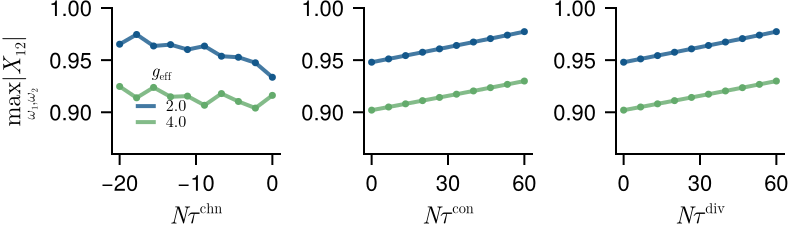

CairoMakie.Screen{IMAGE}


In [5]:
using FFTW

function max_abs_X12_from_time_response(g, χϕ_t, dt)
    χϕ_ω = dt / sqrt(2π) .* fft(χϕ_t)
    return 2π * g^2 * maximum(abs2, χϕ_ω)
end

function max_abs_X12_from_frequency_response(g, χϕ_ω)
    return 2π * g^2 * maximum(abs2, χϕ_ω)
end

chn_data = load("results/TheoreticalPRDchn.jld2")
chn_result = chn_data["result_chn"]
chn_τ = collect(chn_data["τ_chn_vec"])
x_chn = chn_data["N"] .* chn_τ
g_eff_vec = chn_data["g_eff_vec"]
chn_dt = chn_data["dt"]

condiv_data = load("results/TheoreticalPRDcondiv.jld2")
con_τ = collect(condiv_data["result_con"].τ)
div_τ = collect(condiv_data["result_div"].τ)
x_con = condiv_data["N"] .* con_τ
x_div = condiv_data["N"] .* div_τ
con_χϕ_h = condiv_data["result_con"].χϕ_h
div_χϕ_h = condiv_data["result_div"].χϕ_h

max_X12_chn = zeros(length(g_eff_vec), length(chn_τ))
max_X12_con = zeros(length(g_eff_vec), length(con_τ))
max_X12_div = zeros(length(g_eff_vec), length(div_τ))

for (ig, g_eff) in enumerate(g_eff_vec)
    for (iτ, τchn) in enumerate(chn_τ)
        τ = (τchn, 0.0)
        g = compute_g(g_eff, τ)
        max_X12_chn[ig, iτ] = max_abs_X12_from_time_response(g, chn_result[ig, iτ].χϕ, chn_dt)
    end

    for (iτ, τcon) in enumerate(con_τ)
        τ = (0.0, 0.0, τcon, 0.0)
        g = compute_g(g_eff, τ)
        max_X12_con[ig, iτ] = max_abs_X12_from_frequency_response(g, con_χϕ_h[ig])
    end

    for (iτ, τdiv) in enumerate(div_τ)
        τ = (0.0, 0.0, 0.0, τdiv)
        g = compute_g(g_eff, τ)
        max_X12_div[ig, iτ] = max_abs_X12_from_frequency_response(g, div_χϕ_h[ig])
    end
end

set_theme!(DoubleColumnTheme)
fχ = Figure(size=(72 * 5.5, 72 * 1.6), figure_padding=(2, 4, 2, 4))
cmap = to_colormap(:navia10)
g_colors = cmap[[3, 7]]

panels = [
    (x=x_chn, y=max_X12_chn, xlabel=L"N\tau^{\mathrm{chn}}", xticks=-20:10:0),
    (x=x_con, y=max_X12_con, xlabel=L"N\tau^{\mathrm{con}}", xticks=0:30:60),
    (x=x_div, y=max_X12_div, xlabel=L"N\tau^{\mathrm{div}}", xticks=0:30:60)
]

axesχ = Axis[]
for (col, panel) in enumerate(panels)
    ax = Axis(fχ[1, col],
        xlabel=panel.xlabel,
        limits=(nothing, nothing, 0.86, 1.0),
        xticks = panel.xticks

    )
    push!(axesχ, ax)
    if col == 1
        ax.ylabel = L"\max_{\omega_1,\omega_2}|X_{12}|"
    end
    for (ig, g_eff) in enumerate(g_eff_vec)
        lines!(ax, panel.x, panel.y[ig, :]; color=g_colors[ig], linewidth=2.0, label=L"%$(g_eff)", alpha=0.8)
        scatter!(ax, panel.x, panel.y[ig, :]; color=g_colors[ig], markersize=5)
    end
end

linkyaxes!(axesχ...)
axislegend(axesχ[1], L"g_{\mathrm{eff}}"; titlesize=9, position=:lb, patchsize=(10, 4), rowgap=0.0)
colgap!(fχ.layout, 12)
# save("images/ThreeNeuronX12Max.pdf", fχ, pt_per_unit=1)
display(fχ)
